# GAN — Generative Adversarial Networks

## 1. Giới thiệu

**GAN (Mạng đối kháng tạo sinh)** do Ian Goodfellow đề xuất năm 2014, là một trong những ý tưởng đẹp nhất của Deep Learning. GAN gồm hai mạng nơ-ron *cạnh tranh* với nhau:

- **Generator (G)**: nhận vector nhiễu ngẫu nhiên, sinh ra dữ liệu giả.
- **Discriminator (D)**: nhận vào dữ liệu (thật hoặc giả), phán xem là thật hay giả.

Hai mạng được train đồng thời. G cố gắng *lừa* D; D cố gắng *vạch trần* hàng giả của G. Khi cân bằng, G tạo ra dữ liệu gần như không phân biệt được với thật.

Ví dụ hài hước: G là *thợ làm tiền giả* tinh vi dần lên; D là *cảnh sát* tinh tinh hơn. Cuộc rượt đuổi này khiến cả hai cùng giỏi lên — đến mức cảnh sát phải đoán bừa thì tiền giả đã gần như y hệt tiền thật.

### Ứng dụng nổi bật
- Sinh ảnh chân dung không có thật (StyleGAN).
- Chuyển ảnh từ phong cách này sang phong cách khác (CycleGAN: ảnh ngựa → ngựa vằn).
- Tăng cường dữ liệu (data augmentation).
- Sinh ảnh từ text (sau này được kế thừa bởi diffusion models).

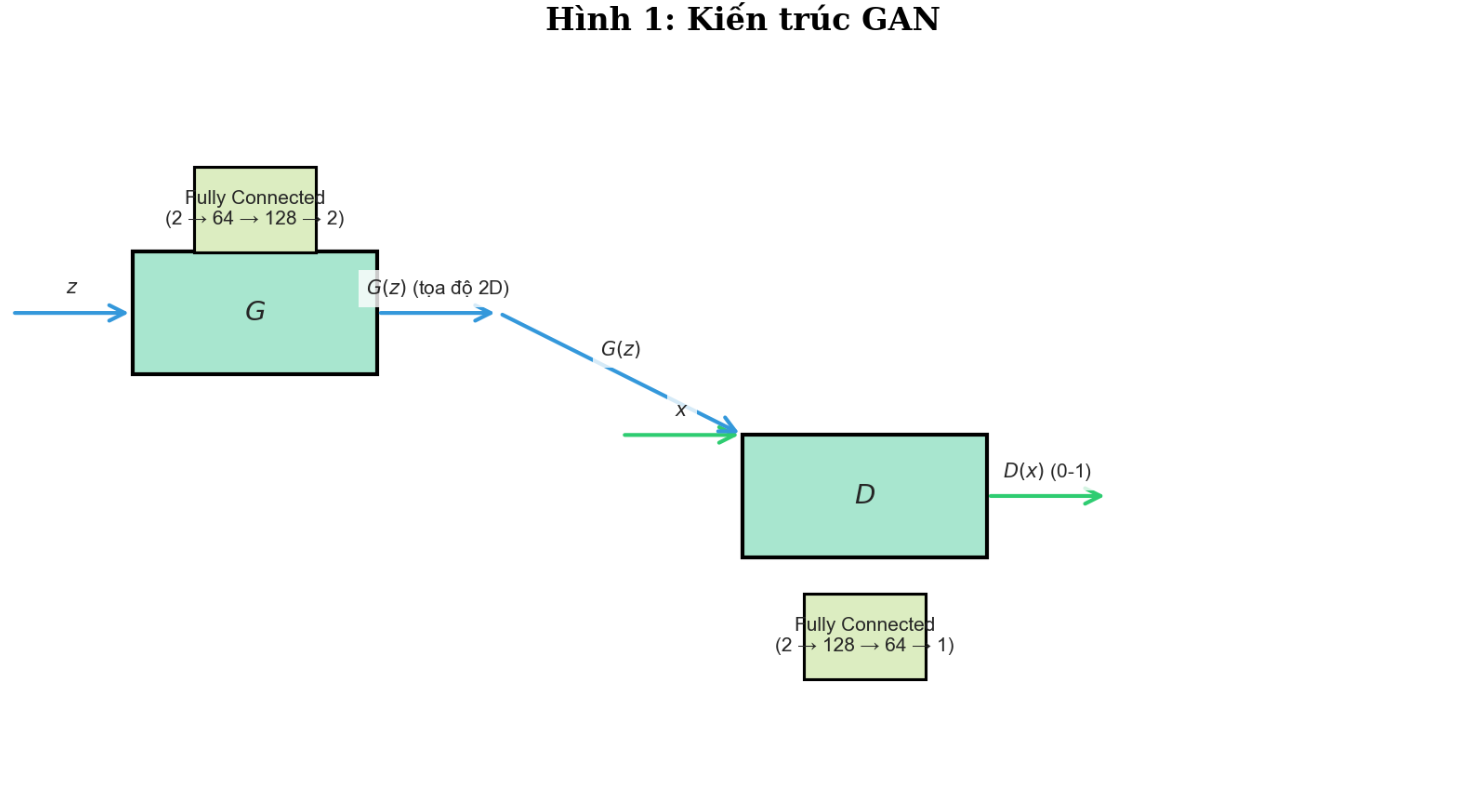


## 2. Hàm mục tiêu — Trò chơi minimax

Ý tưởng toán học của GAN gói gọn trong một công thức:
$$
\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}}\big[\log D(x)\big] + \mathbb{E}_{z \sim p_z}\big[\log(1 - D(G(z)))\big]
$$

**Discriminator muốn cực đại $V$**:
- Đưa $D(x) \to 1$ với $x$ thật → $\log D(x) \to 0$ (lớn nhất có thể, vì $\log < 0$).
- Đưa $D(G(z)) \to 0$ với $G(z)$ giả → $\log(1 - D(G(z))) \to 0$ (lớn nhất có thể).

**Generator muốn cực tiểu $V$**: làm $D(G(z)) \to 1$ để $\log(1 - D(G(z))) \to -\infty$.

### Lý thuyết: Discriminator tối ưu
Với $G$ cố định, $D$ tối ưu là:
$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_G(x)}$$

Khi $G$ học hoàn hảo ($p_G = p_{\text{data}}$), $D^*(x) = 1/2$ ở mọi nơi — D không phân biệt được nữa. Đây cũng là lý do trong thực tế, khi GAN cân bằng, ta thấy `D loss ≈ G loss ≈ log(2) ≈ 0.69`.

### Diễn giải bằng JS-divergence
Có thể chứng minh rằng tối thiểu hoá $V$ tương đương với tối thiểu hoá *Jensen-Shannon divergence* giữa $p_G$ và $p_{\text{data}}$. Tức là GAN đang trực tiếp tối thiểu hoá khoảng cách giữa hai phân phối — không cần biết phân phối thật $p_{\text{data}}$ trông như thế nào, chỉ cần lấy mẫu được từ nó.

## 3. Hàm mất mát thực tế

### Discriminator loss (theo cross-entropy)
$$
L_D = -\frac{1}{m}\sum_{i=1}^{m}\big[\log D(x^{(i)}) + \log(1 - D(G(z^{(i)})))\big]
$$

**Ví dụ số:** batch $m=2$ với $D(x_1)=0.8$, $D(x_2)=0.9$, $D(G(z_1))=0.3$, $D(G(z_2))=0.4$.
$$L_D = -\tfrac{1}{2}\big[\log 0.8 + \log 0.7 + \log 0.9 + \log 0.6\big]$$
$$ = -\tfrac{1}{2}[-0.223 - 0.357 - 0.105 - 0.511] = -\tfrac{1}{2}(-1.196) = 0.598$$

### Generator loss — phiên bản non-saturating
Bài báo gốc đề xuất G tối thiểu hoá $\log(1 - D(G(z)))$. Vấn đề: lúc đầu khi G còn yếu, $D(G(z)) \approx 0$, nên $\log(1-D(G(z))) \approx 0$ → gradient *bão hoà* → G không học được.

Trong thực tế, ta dùng phiên bản **non-saturating**: G *cực đại hoá* $\log D(G(z))$, tức là tối thiểu hoá:
$$
L_G = -\frac{1}{m}\sum_{i=1}^{m} \log D(G(z^{(i)}))
$$

Hai cách này có cùng điểm cân bằng, nhưng phiên bản non-saturating có gradient mạnh hơn lúc đầu.

## 4. Quy trình huấn luyện

Tại mỗi vòng lặp:
1. **Update D**: lấy batch $x$ thật + sinh $G(z)$ giả → tính $L_D$ → backward → step.
2. **Update G**: lấy nhiễu $z$ mới → sinh $G(z)$ → tính $L_G$ → backward → step.

Lưu ý:
- Khi update D, phải `detach()` $G(z)$ để gradient không chảy ngược vào G.
- Đôi khi train D nhiều bước hơn G (k bước D rồi 1 bước G) để giữ cân bằng.
- Một số biến thể (WGAN, LSGAN) thay đổi loss function để ổn định hơn — sẽ học sau.

## 5. Vấn đề thường gặp

- **Mode collapse**: G chỉ sinh ra một vài mẫu giống nhau lặp đi lặp lại (ví dụ chỉ sinh ra số 1 thay vì cả 10 chữ số). Cách khắc phục: tăng `noise_dim`, dùng kỹ thuật như mini-batch discrimination, WGAN.
- **Train không ổn định**: D quá khoẻ → G không học được. Cân nhắc giảm lr, thêm noise vào D's input, dùng spectral normalization.
- **Vanishing gradient cho G**: dùng non-saturating loss như đã nói ở mục 3.

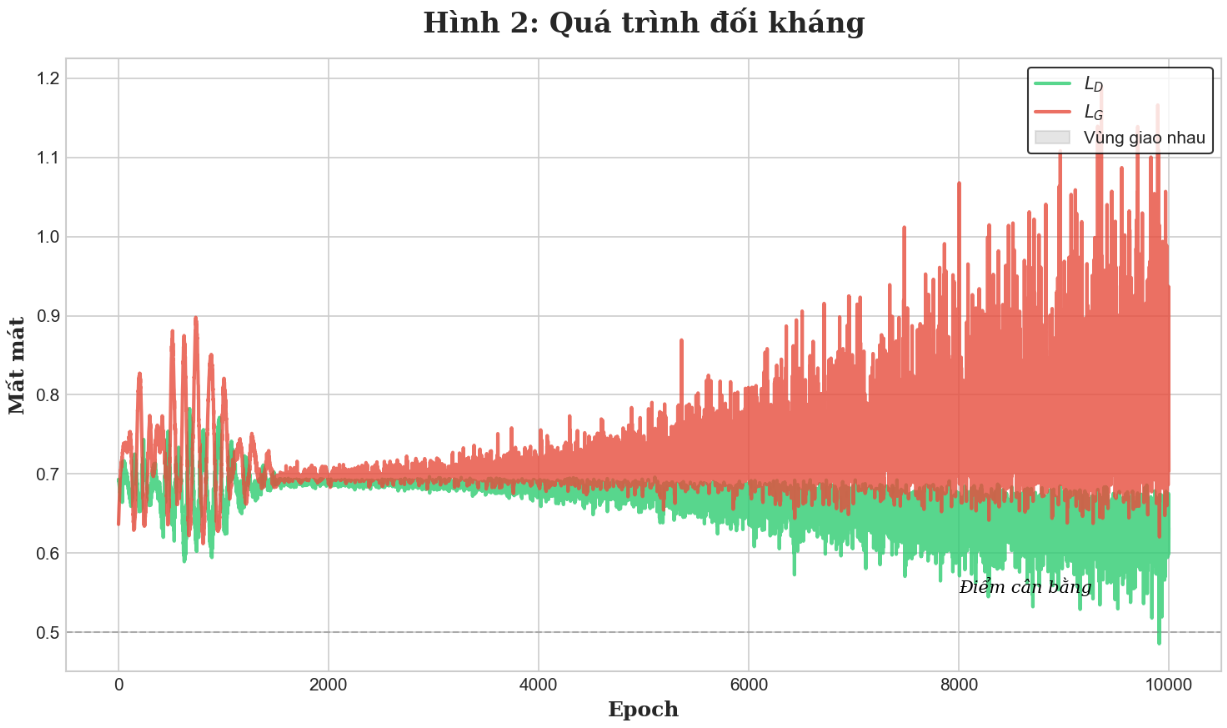


# BÀI THỰC HÀNH: GAN sinh điểm trên đường tròn

Dữ liệu thật: 1000 điểm $(x, y) = (\cos\theta, \sin\theta)$ trên đường tròn đơn vị. Ta train một GAN để sinh điểm cũng nằm trên (xấp xỉ) đường tròn này.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def make_real_data(n=1000):
    theta = 2 * np.pi * np.random.rand(n)
    x = np.cos(theta); y = np.sin(theta)
    return torch.tensor(np.stack([x, y], axis=1), dtype=torch.float32)

real_data = make_real_data().to(device)

plt.figure(figsize=(5, 5))
plt.scatter(real_data.cpu()[:, 0], real_data.cpu()[:, 1], s=10, alpha=0.5)
plt.title('1000 điểm trên đường tròn đơn vị (dữ liệu thật)')
plt.axis('equal'); plt.grid(alpha=0.3); plt.show()

### Kiến trúc

Chọn `noise_dim = 16` (thay vì 2 như cách làm naive) để latent space có *thừa* — giúp G dễ học mapping đa dạng và tránh mode collapse.

Discriminator dùng `BCEWithLogitsLoss` thay cho `BCELoss + Sigmoid`, ổn định số học hơn (không bị NaN khi logits cực lớn/cực nhỏ).

In [ ]:
noise_dim = 16

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),     # trả về logit (chưa sigmoid) — đi với BCEWithLogitsLoss
        )
    def forward(self, x):
        return self.net(x)

G = Generator(noise_dim, 2).to(device)
D = Discriminator(2).to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

### Vòng lặp huấn luyện

Train 8000 vòng. Lưu snapshot G(z) tại các epoch 0, 1000, 4000, 7999 để vẽ tiến trình.

In [ ]:
epochs = 8000
batch_size = 64
loss_D_hist, loss_G_hist = [], []
milestones = [0, 1000, 4000, epochs - 1]
snapshots = {}

for epoch in range(epochs):
    # ----- Update D -----
    G.train(); D.train()
    idx = torch.randint(0, len(real_data), (batch_size,))
    real_batch = real_data[idx]
    z = torch.randn(batch_size, noise_dim, device=device)
    fake_batch = G(z).detach()                          # detach để không backprop về G

    real_logits = D(real_batch)
    fake_logits = D(fake_batch)
    loss_D = (criterion(real_logits, torch.ones_like(real_logits)) +
              criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()

    # ----- Update G -----
    z = torch.randn(batch_size, noise_dim, device=device)
    fake_batch = G(z)
    fake_logits = D(fake_batch)
    # Non-saturating: G muốn D đánh giá fake là thật → label = 1.
    loss_G = criterion(fake_logits, torch.ones_like(fake_logits))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    loss_D_hist.append(loss_D.item())
    loss_G_hist.append(loss_G.item())

    if epoch in milestones:
        # Khi sample, G phải ở chế độ eval vì có BatchNorm.
        G.eval()
        with torch.no_grad():
            z_vis = torch.randn(1000, noise_dim, device=device)
            snapshots[epoch] = G(z_vis).cpu().numpy()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1:5d}/{epochs}  L_D = {loss_D.item():.4f}  L_G = {loss_G.item():.4f}')

### Trực quan kết quả

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, ep in zip(axes.flat, milestones):
    fake = snapshots[ep]
    ax.scatter(real_data.cpu()[:, 0], real_data.cpu()[:, 1], s=8, alpha=0.3, label='Thật')
    ax.scatter(fake[:, 0], fake[:, 1], s=8, alpha=0.5, color='red', label='Giả')
    ax.set_title(f'Epoch {ep+1}')
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle('Tiến trình GAN học đường tròn', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='$L_D$', alpha=0.7)
plt.plot(loss_G_hist, label='$L_G$', alpha=0.7)
plt.axhline(np.log(2), color='black', linestyle='--', label=r'$\log 2 \approx 0.69$ (cân bằng)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Hai loss dao động quanh log(2) — dấu hiệu cân bằng GAN')
plt.show()

### Quan sát

- Sau 8000 epoch, các điểm giả phân bố sát đường tròn.
- Cả hai loss dao động quanh $\log(2) \approx 0.69$ — đúng giá trị lý thuyết khi GAN cân bằng.
- Nếu thấy `L_D → 0` và `L_G → ∞`: D quá khoẻ, G không học được → giảm lr của D hoặc thêm noise.
- Nếu thấy fake points chỉ tụ ở vài điểm → mode collapse.

## Câu hỏi suy nghĩ

1. Thay `noise_dim` lần lượt bằng 1, 2, 16, 64 và xem kết quả. `noise_dim` quá nhỏ tạo hiện tượng gì?
2. Tăng số epoch lên 20000 hoặc giảm xuống 2000. Loss thay đổi thế nào?
3. Thêm tầng ẩn vào G hoặc D. Có cải thiện không?
4. Thay `LeakyReLU(0.2)` bằng `ReLU` hoặc `Tanh` ở G. Quá trình train có khác không?
5. Bỏ `BatchNorm1d` ra. Hiện tượng gì xuất hiện?

# BÀI TẬP VỀ NHÀ: GAN sinh ảnh chữ số MNIST

Em sẽ áp dụng kiến thức ở phần trên để xây một GAN sinh ảnh 28×28 trông giống chữ số MNIST. Code skeleton đã có ở dưới — em điền vào các chỗ `# CODE HERE`.

Skeleton cố ý chừa nhiều phần để em phải nghĩ. Hint cho từng chỗ trống đặt ngay bên cạnh.

## Yêu cầu nộp
1. Notebook hoàn chỉnh, train ít nhất 50 epoch.
2. Vẽ ảnh giả ở các epoch 1, 10, 30, 50.
3. Vẽ đồ thị $L_D$, $L_G$.
4. Markdown ngắn (5-10 dòng) trả lời:
   - Loss có dao động quanh log(2) không?
   - Sau 50 epoch, các chữ số sinh ra dễ nhận hay vẫn nguệch ngoạc?
   - Có hiện tượng mode collapse (ví dụ chỉ sinh ra một chữ số) không?

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Chuẩn hoá MNIST về [-1, 1] để tương thích với Tanh ở output của Generator.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(mnist, batch_size=128, shuffle=True, drop_last=True)

In [ ]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Hint: chuỗi Linear → LeakyReLU → ... → Tanh.
        # Cấu trúc gợi ý: z_dim(100) → 256 → 512 → 1024 → img_dim(784).
        # Dùng nn.Sequential cho gọn.
        self.net = nn.Sequential(
            # CODE HERE: nn.Linear(z_dim, 256)
            # CODE HERE: nn.LeakyReLU(0.2)
            # CODE HERE: nn.Linear(256, 512) + BatchNorm1d(512) + LeakyReLU(0.2)
            # CODE HERE: nn.Linear(512, 1024) + BatchNorm1d(1024) + LeakyReLU(0.2)
            # CODE HERE: nn.Linear(1024, img_dim)
            # CODE HERE: nn.Tanh()    # đẩy về [-1, 1] khớp với chuẩn hoá ảnh
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Hint: img_dim(784) → 512 → 256 → 1.
        # KHÔNG có Sigmoid ở cuối — sẽ dùng BCEWithLogitsLoss.
        # Có thể thêm nn.Dropout(0.3) sau LeakyReLU để D không quá khoẻ.
        self.net = nn.Sequential(
            # CODE HERE
        )

    def forward(self, x):
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)

# CODE HERE: criterion = nn.BCEWithLogitsLoss()
# CODE HERE: opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
# CODE HERE: opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
num_epochs = 50
milestone_epochs = [0, 9, 29, 49]    # 1, 10, 30, 50 (0-indexed)
snapshots = {}
loss_D_hist, loss_G_hist = [], []

for epoch in range(num_epochs):
    G.train(); D.train()
    epoch_loss_D, epoch_loss_G, n_batches = 0.0, 0.0, 0
    for real_imgs, _ in loader:
        bsz = real_imgs.size(0)
        # Đưa ảnh thành vector 784, chuyển lên device.
        # CODE HERE: real_imgs = real_imgs.view(bsz, -1).to(device)

        # ===== Update D =====
        # CODE HERE: opt_D.zero_grad()
        # CODE HERE: real_logits = D(real_imgs)
        # CODE HERE: z = torch.randn(bsz, z_dim, device=device)
        # CODE HERE: fake_imgs = G(z).detach()
        # CODE HERE: fake_logits = D(fake_imgs)
        # CODE HERE: loss_D = (criterion(real_logits, torch.ones_like(real_logits))
        #                   + criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
        # CODE HERE: loss_D.backward(); opt_D.step()

        # ===== Update G =====
        # CODE HERE: opt_G.zero_grad()
        # CODE HERE: z = torch.randn(bsz, z_dim, device=device)
        # CODE HERE: fake_logits = D(G(z))
        # CODE HERE: loss_G = criterion(fake_logits, torch.ones_like(fake_logits))   # non-saturating
        # CODE HERE: loss_G.backward(); opt_G.step()

        # CODE HERE: epoch_loss_D += loss_D.item(); epoch_loss_G += loss_G.item(); n_batches += 1
        pass     # bỏ dòng này khi điền code

    # CODE HERE: loss_D_hist.append(epoch_loss_D / n_batches)
    # CODE HERE: loss_G_hist.append(epoch_loss_G / n_batches)

    if epoch in milestone_epochs:
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, z_dim, device=device)
            samples = G(z).view(-1, 28, 28).cpu().numpy()
        snapshots[epoch] = samples

    print(f'Epoch {epoch+1:3d}/{num_epochs}  '
          # CODE HERE: f'L_D = {loss_D_hist[-1]:.4f}  L_G = {loss_G_hist[-1]:.4f}'
          )

In [ ]:
# Vẽ ảnh giả ở các milestone
fig, axes = plt.subplots(len(milestone_epochs), 8, figsize=(14, 1.6 * len(milestone_epochs)))
for r, ep in enumerate(milestone_epochs):
    if ep not in snapshots: continue
    for c in range(8):
        axes[r, c].imshow(snapshots[ep][c], cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(f'Epoch {ep+1}', fontsize=12, rotation=0, ha='right', va='center')
plt.suptitle('Ảnh chữ số sinh ra qua các epoch')
plt.tight_layout(); plt.show()

# Vẽ loss
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='$L_D$')
plt.plot(loss_G_hist, label='$L_G$')
plt.axhline(np.log(2), color='black', linestyle='--', label='log(2)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Bài tập mở rộng (không bắt buộc)

- **Conditional GAN**: thêm label vào input của G và D (ví dụ one-hot 10 chữ số), để G sinh ra đúng chữ số mình muốn. Gợi ý: concat label với z trước khi đưa vào G; concat label với ảnh trước khi đưa vào D.
- **DCGAN**: thay các tầng Linear bằng Conv2d / ConvTranspose2d. Ảnh kết quả thường sắc nét hơn nhiều.
- **Đo mode collapse**: tính số lượng cluster phân biệt được trong 1000 ảnh sinh ra (bằng K-means trên ảnh hoặc đếm class bằng một classifier MNIST có sẵn).

## Hạn nộp
10/04/2026.